In [6]:
"""data = {    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5, 11.2, 11.5, 12.3, 12.9, 13.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872, 127345, 126756, 128765, 135673, 139465]
}
df = pd.DataFrame(data)
"""

"data = {    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5, 11.2, 11.5, 12.3, 12.9, 13.5],\n    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189, 63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872, 127345, 126756, 128765, 135673, 139465]\n}\ndf = pd.DataFrame(data)\n"

# 1. Data Preparation
### <p> a)Import Libraries</i>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


### <p> b) Create the DataFrame


In [8]:

df = pd.read_csv('/content/drive/MyDrive/Datasets/Salary.csv')
print(f"{df.columns,df.info()}\n")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes
(Index(['YearsExperience', 'Salary'], dtype='object'), None)



,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


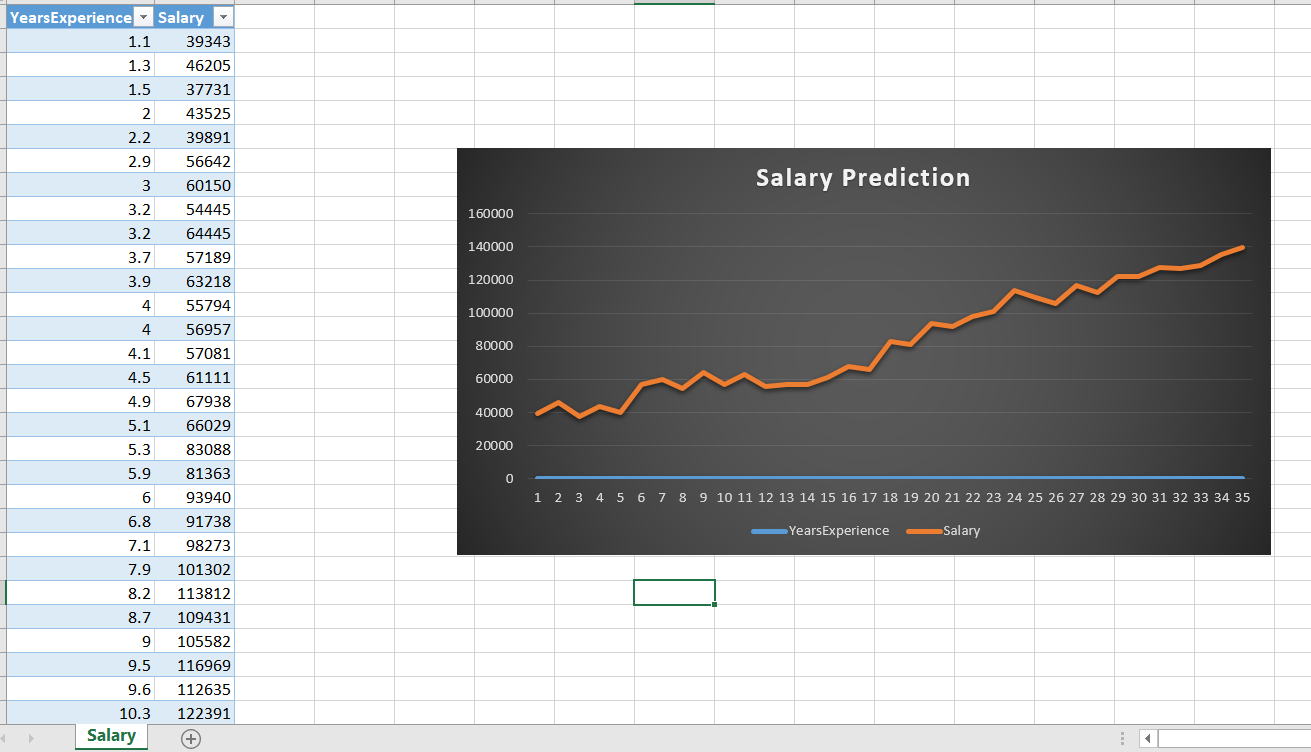

From above line-graph it is clear that it support Linear Regression


$\hat{y} =  β_0 +β_1*x1$

where,
 - y : Prediction Output
 - x1: Input feature
 - β_0:Intercept (starting value when x=0)
 - β_1: Slope(m) which is multiplied with input feature and added to intercept to form linear
  

### <p> c) Separate features (X) and target (y)
##### X must be reshaped for scikit-learn, as it expects a 2D array

In [10]:

X = df[['YearsExperience']]
y = df['Salary']


###<p> d) Split the data into Training and Test sets
# This is crucial for evaluating how well the model generalizes to new, unseen data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 24 samples
Test set size: 11 samples


# 2. <u>Model Training</u>
Now, train the simple linear regression model using the training data
#### a) Create the Linear Regression model object


In [12]:
lr = LinearRegression()


### b) Train the model using the training data


In [13]:
lr.fit(X_train, y_train)

LinearRegression()

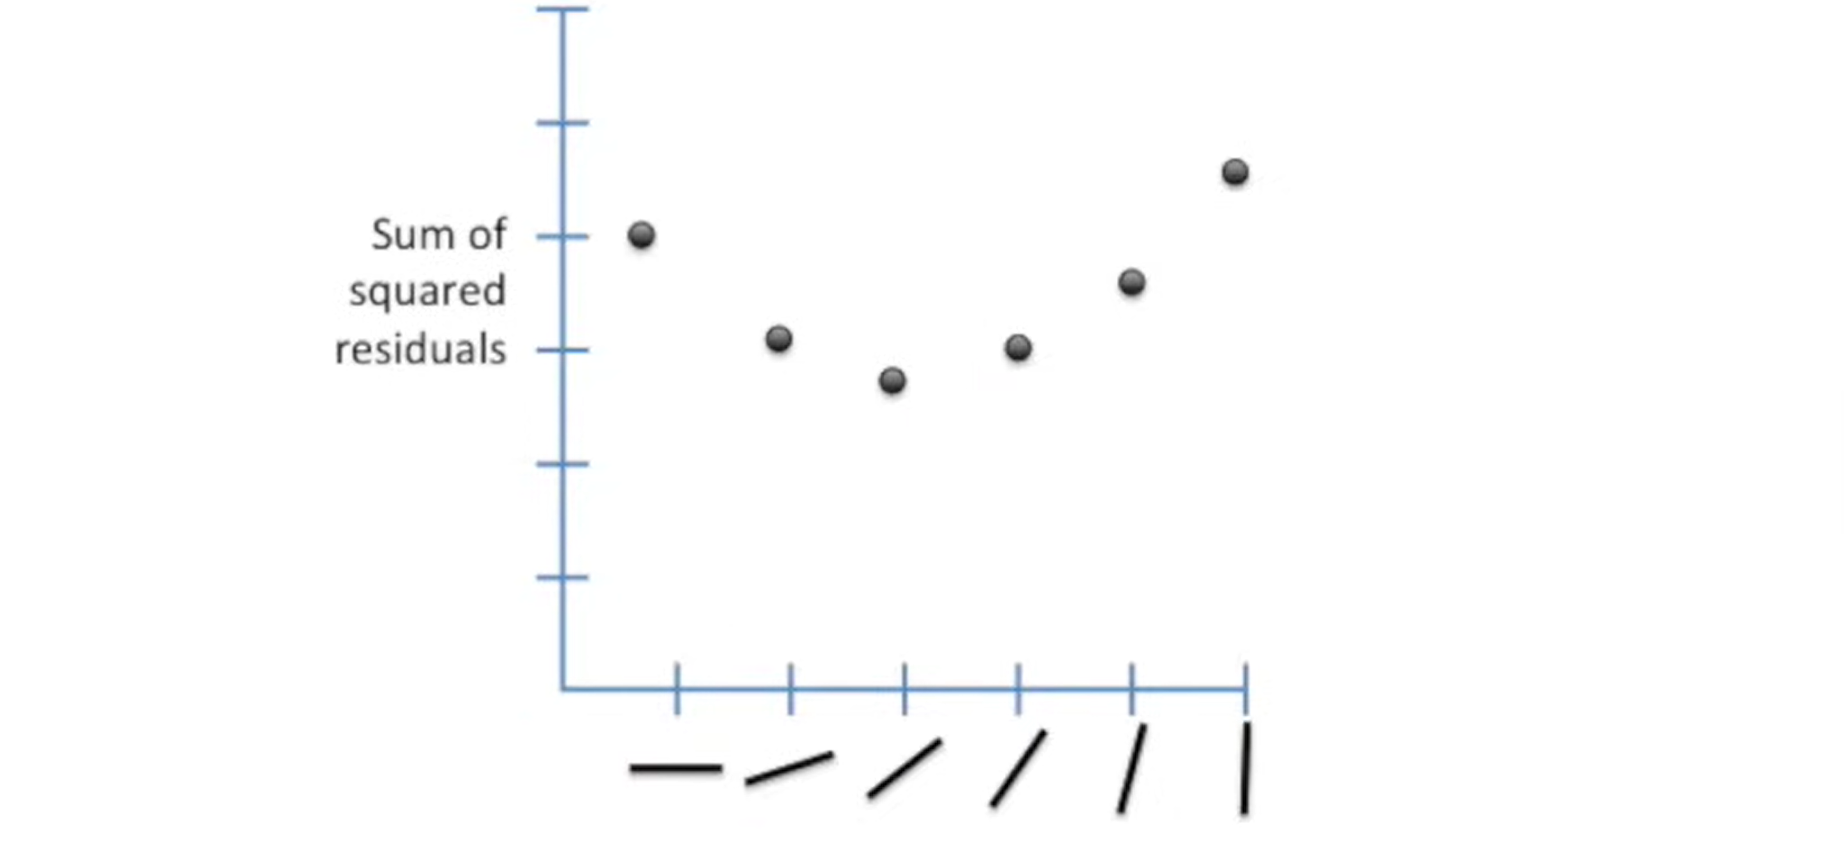

### c) Generate Model Parameters

In [14]:
# Output the learned parameters
print("\n--- Model Parameters ---")
# The coefficient (slope, β1)
print(f"Coefficient (Slope, β1): {lr.coef_[0]:.2f}")
# The intercept (y-intercept, β0)
print(f"Intercept (β0): {lr.intercept_:.2f}")

# The linear model equation is: Salary = 9202.23 * YearsExperience + 25321.58 (approx)


--- Model Parameters ---
Coefficient (Slope, β1): 8555.34
Intercept (β0): 29602.07


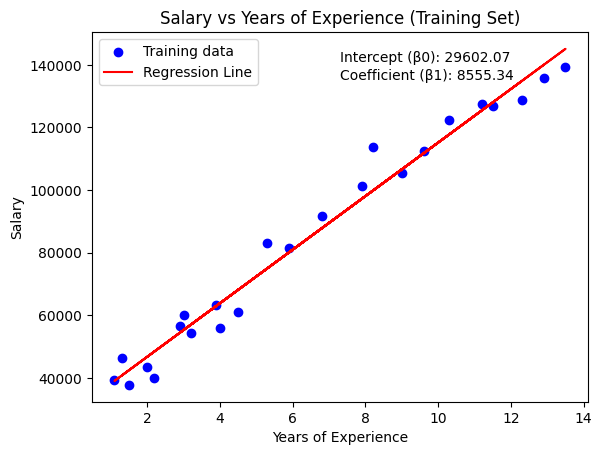

In [15]:
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.plot(X_train, lr.predict(X_train), color='red', label='Regression Line')

# Add intercept and coefficient to the graph
intercept_val = lr.intercept_
coefficient_val = lr.coef_[0]

plt.text(0.5, 0.95, f'Intercept (β0): {intercept_val:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.5, 0.90, f'Coefficient (β1): {coefficient_val:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.title('Salary vs Years of Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

# 3. <u>Model Prediction & Evaluation</u>
#### a. Make predictions on the Test set

In [16]:
y_pred = lr.predict(X_test)


### b) Evaluate the Model Performance
1.   R-squared (R2): Measures how wellthe regression line fits the data (0 to 1). Higher is better.

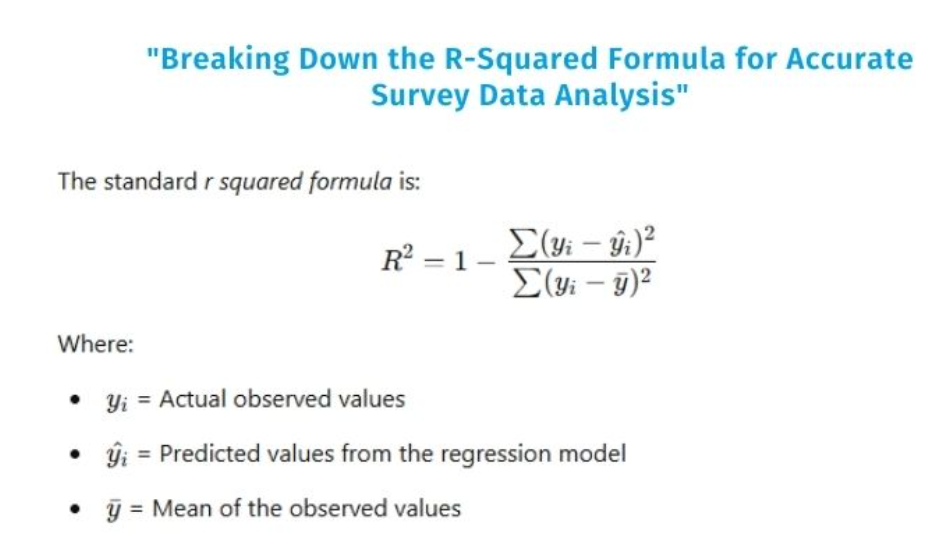

2. Mean Absolute Error (MAE): The average magnitude of the errors. Lower is better.

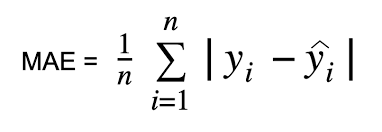

In [17]:
print("\n--- Model Evaluation ---")
# R-squared (R2):
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2): {r2:.4f}")
# Mean Absolute Error (MAE):
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")


--- Model Evaluation ---
R-squared (R2): 0.9171
Mean Absolute Error (MAE): $6513.64


**R2_Score**
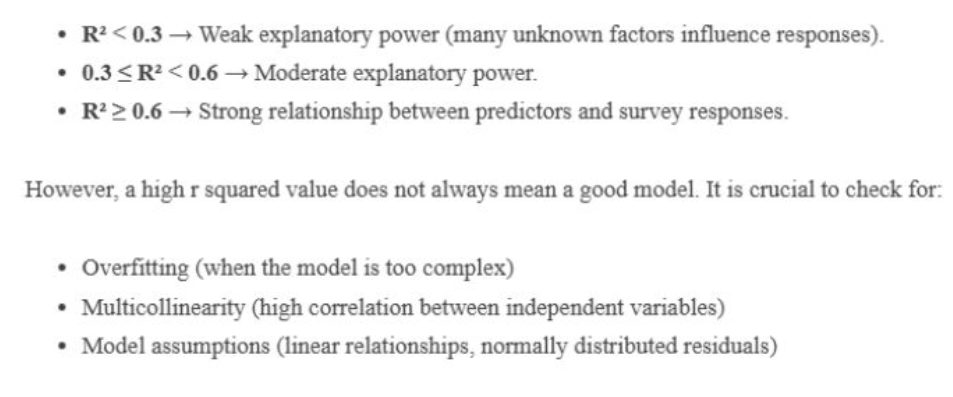



## <u><i>Loss and Gradient

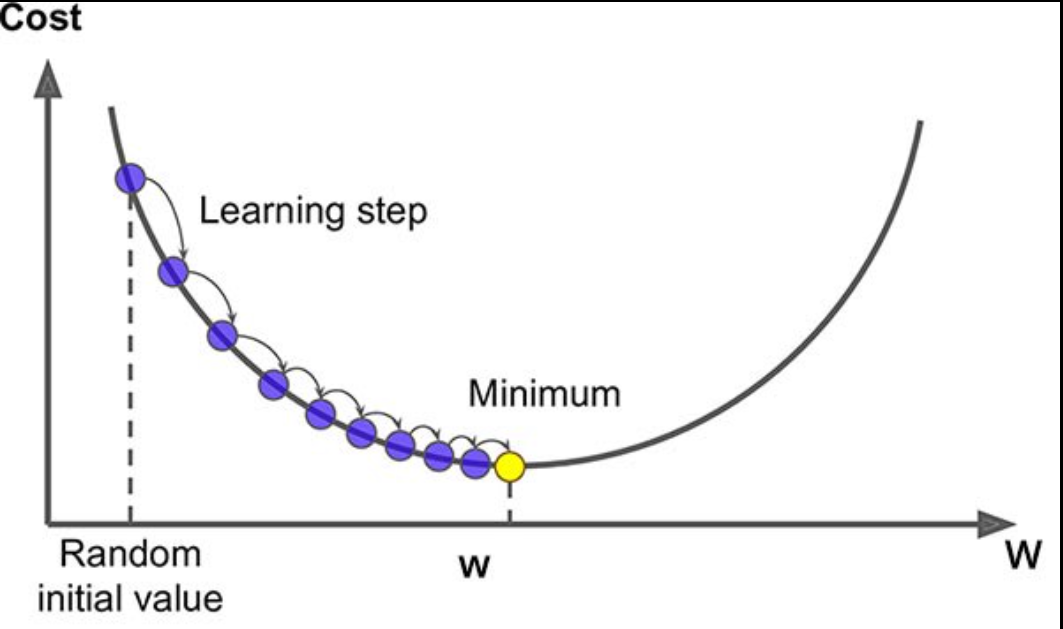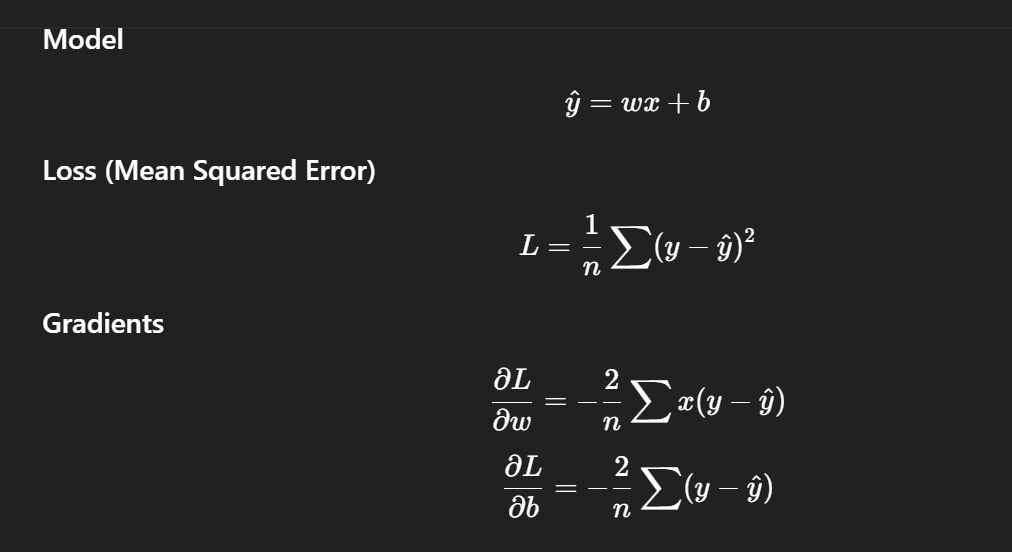

## Stochastic Gradient Descent (SGD)


--- SGDRegressor Model Parameters ---
Coefficient (Slope, β1) from SGD: 9622.95
Intercept (β0) from SGD: 19859.10

--- SGDRegressor Model Evaluation ---
R-squared (R2) from SGD: 0.9020
Mean Absolute Error (MAE) from SGD: $5629.76


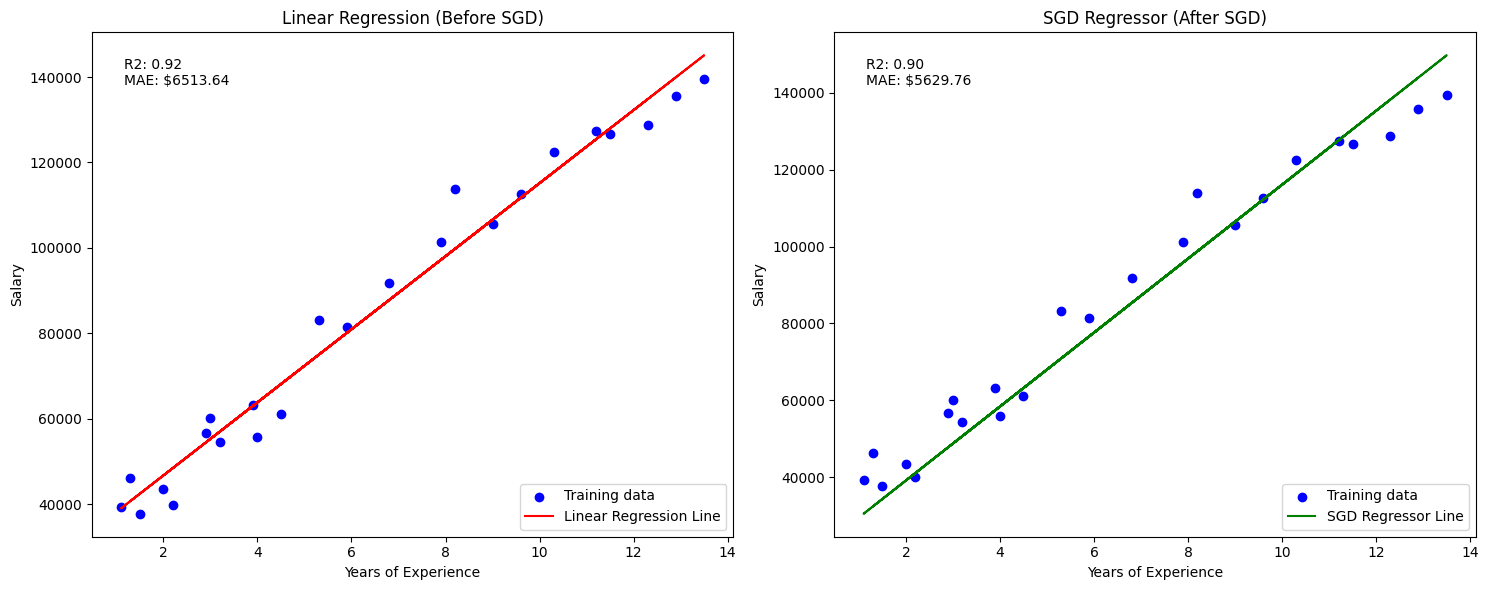

In [21]:
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

# Create an SGDRegressor model
# You might need to adjust parameters like max_iter, tol, and learning_rate (eta0) for optimal performance
sgd_lr = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, random_state=42)

# Train the model using the training data
sgd_lr.fit(X_train, y_train)

# Output the learned parameters from the SGDRegressor
print("\n--- SGDRegressor Model Parameters ---")
print(f"Coefficient (Slope, β1) from SGD: {sgd_lr.coef_[0]:.2f}")
print(f"Intercept (β0) from SGD: {sgd_lr.intercept_[0]:.2f}")

# Evaluate the SGDRegressor model performance
sgd_y_pred = sgd_lr.predict(X_test)
sgd_r2 = r2_score(y_test, sgd_y_pred)
sgd_mae = mean_absolute_error(y_test, sgd_y_pred)

print("\n--- SGDRegressor Model Evaluation ---")
print(f"R-squared (R2) from SGD: {sgd_r2:.4f}")
print(f"Mean Absolute Error (MAE) from SGD: ${sgd_mae:.2f}")

# Create a figure with two subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for LinearRegression (before gradient programming)
axes[0].scatter(X_train, y_train, color='blue', label='Training data')
axes[0].plot(X_train, lr.predict(X_train), color='red', label='Linear Regression Line')
axes[0].set_title('Linear Regression (Before SGD)')
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Salary')
axes[0].text(0.05, 0.95, f'R2: {r2:.2f}\nMAE: ${mae:.2f}', transform=axes[0].transAxes, fontsize=10, verticalalignment='top')
axes[0].legend()

# Plot for SGDRegressor (after gradient programming)
axes[1].scatter(X_train, y_train, color='blue', label='Training data')
axes[1].plot(X_train, sgd_lr.predict(X_train), color='green', label='SGD Regressor Line')
axes[1].set_title('SGD Regressor (After SGD)')
axes[1].set_xlabel('Years of Experience')
axes[1].set_ylabel('Salary')
axes[1].text(0.05, 0.95, f'R2: {sgd_r2:.2f}\nMAE: ${sgd_mae:.2f}', transform=axes[1].transAxes, fontsize=10, verticalalignment='top')
axes[1].legend()

plt.tight_layout()
plt.show()

### c. Prediction

In [32]:
print("Tesing")
new_experience = float(input("Enter years of experience to predict salary: ")) # Prompt user for input
# Need to reshape the input for a single prediction and maintain feature names
new_X = pd.DataFrame({'YearsExperience': [new_experience]})
predicted_salary = lr.predict(new_X)[0]
print(f"\nPredicted Monthly Salary without error adjusting for {new_experience} years experience = ${predicted_salary:,.2f}")

predicted_salary_gd = sgd_lr.predict(new_X)[0]
print(f"\nPredicted Monthly Salary after gradient error adjustingfor {new_experience} years experience = ${predicted_salary_gd:,.2f}")


Tesing
*******
Enter years of experience to predict salary: 532

Predicted Monthly Salary without error adjusting for 532.0 years experience = $4,581,042.52

Predicted Monthly Salary after gradient error adjustingfor 532.0 years experience = $5,139,267.33


## <u>Final Prediction :

In [34]:
print("Salary Prediction Model")
print("*" * len("Salary Prediction Model"))
new_experience = float(input("Enter years of experience to predict salary: "))
new_X = pd.DataFrame({'YearsExperience': [new_experience]})
predicted_salary_gd = sgd_lr.predict(new_X)[0]
print(f"\nPredicted Monthly Salary for {new_experience} years experience = ${predicted_salary_gd:,.2f}")


Salary Prediction Model
***********************
Enter years of experience to predict salary: 25

Predicted Monthly Salary for 25.0 years experience = $260,432.79
